##  Step 1: Environment Setup & Library Imports
**Objective:** Initialize the data science environment and import essential libraries for data manipulation, machine learning, and visual analytics.
In this section, we load all the necessary libraries, including those for Data Engineering (`pandas`, `numpy`), Machine Learning (`scikit-learn`), and Data Visualization (`matplotlib`, `seaborn`).

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from sklearn.pipeline import Pipeline
from IPython.display import display, clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## Step 2: Data Ingestion & The "Strict No-Drop" Policy
**Objective:** Load the global football dataset encompassing 98 multidimensional attributes without applying arbitrary feature reduction.
We define all **98 columns** as required and separate categorical (text) data from numerical/ML features to adhere to the strict No-Drop Policy.

In [22]:
# 1. Define all 98 columns as specified by the requirements
all_user_columns = [
    'Name', 'Position', 'Age', 'ca', 'pa', 'Nationality', 'Club', 'Corners', 'Crossing', 
    'Dribbling', 'Finishing', 'First Touch', 'Free Kick Taking', 'Heading', 'Long Shots', 
    'Long Throws', 'Marking', 'Passing', 'Penalty Taking', 'Tackling', 'Technique', 
    'Aggression', 'Anticipation', 'Bravery', 'Composure', 'Concentration', 'Vision', 
    'Decisions', 'Determination', 'Flair', 'Leadership', 'Off The Ball', 'Positioning', 
    'Teamwork', 'Work Rate', 'Acceleration', 'Agility', 'Balance', 'Jumping Reach', 
    'Natural Fitness', 'Pace', 'Stamina', 'Strength', 'Stability', 'Foul', 
    'Contest performance', 'Injury', 'diversity', 'Aerial Reach', 'Command Of Area', 
    'Communication', 'Eccentricity', 'Handling', 'Kicking', 'One On Ones', 'Reflexes', 
    'Rushing Out', 'Punching', 'Throwing', 'Adaptation', 'Ambition', 'Argue', 'Loyal', 
    'Resistant to stress', 'Professional', 'Sportsmanship', 'Emotional control', 
    'GK', 'DL', 'DC', 'DR', 'WBL', 'WBR', 'DM', 'ML', 'MC', 'MR', 'AML', 'AMC', 'AMR', 'ST', 
    'Height', 'Weight', 'Left Foot', 'Right Foot', 'Values', 'Current reputation', 
    'Domestic reputation', 'World reputation', 'Race', 'RCA', 'Colour of skin', 
    'Date of birth', 'Number of national team appearances', 'Goals scored for the national team', 
    'Salary', 'Rental club', 'UID'
]

categorical_cols = ['Name', 'Position', 'Nationality', 'Club', 'Race', 'Colour of skin', 'Date of birth', 'Rental club', 'UID']
ml_features = [col for col in all_user_columns if col not in categorical_cols]

# 2. Load dataset
try:
    df = pd.read_csv("fm_dataset.csv", low_memory=False) 
    print(f"Step 2: Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: Dataset file not found. Please check the directory.")

Step 2: Dataset loaded successfully. Shape: (8452, 98)


## Step 3: Data Cleansing & Target Engineering
**Objective:** Sanitize the dataset using Regular Expressions and engineer a proxy target for unsupervised hyperparameter tuning.
Raw data often contains special characters (e.g., currency symbols in the payout column). This code will use `Regex` to clean up garbage, imputation of empty values, and create a `Gen_Pos` column to serve as a proxy target for evaluating model accuracy.

In [23]:
# Handle missing values globally
df = df.replace('-', np.nan)

# Clean characters and handle missing values for ML features
for col in ml_features:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['Name'] = df['Name'].fillna('Unknown')
df['Club'] = df['Club'].fillna('Free Agent')
if 'UID' in df.columns: 
    df['UID'] = df['UID'].fillna(0).astype(int).astype(str)
else: 
    df['UID'] = df.index.astype(str)
df['Display_Name'] = df['Name'] + " (" + df['Club'] + ")"

# Create 'Ground Truth' (Proxy Target) for GridSearch based on General Position
df['Gen_Pos'] = df['Position'].astype(str).str.split('/').str[0].str.split().str[0].str.replace(r'[^a-zA-Z]', '', regex=True)
df['Gen_Pos'] = df['Gen_Pos'].replace({'': 'Unknown'})

## Step 4: Standardization (Z-Score Normalization)
**Objective:** Mitigate scale imbalance across the high-dimensional space to prevent financial metrics from overshadowing technical attributes.
To solve the problem of salaries/transfer fees (in the millions) obscuring football skill values ​​(in the tens), we use `StandardScaler` to convert all data to the same scale (Mean = 0, SD = 1).

In [24]:
available_ml_features = [c for c in ml_features if c in df.columns]
X_raw = df[available_ml_features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Step 4: Standardization complete. Matrix shape: {X_scaled.shape}")

Step 4: Standardization complete. Matrix shape: (8452, 89)


## Step 5: Hyperparameter Tuning & Visual Evaluation
**Objective:** Optimize algorithms via Cross-Validation and Silhouette Analysis, lock the Random Seed for reproducibility, and visualize the performance metrics.
We use `GridSearchCV` to find the best $K$ value for K-NN and use `Silhouette Score` to evaluate the quality of K-Means. The system will plot **Evaluation Charts** to provide statistical evidence of accuracy.

Initiating Hyperparameter Tuning (GridSearch & Silhouette Analysis)

K-NN Optimal Parameter   : K = 7 (Proxy Task Accuracy: 80.93%)
K-Means Optimal Cluster  : K = 10 (Highest Silhouette Score)

Generating Visual Analytics for Model Evaluation


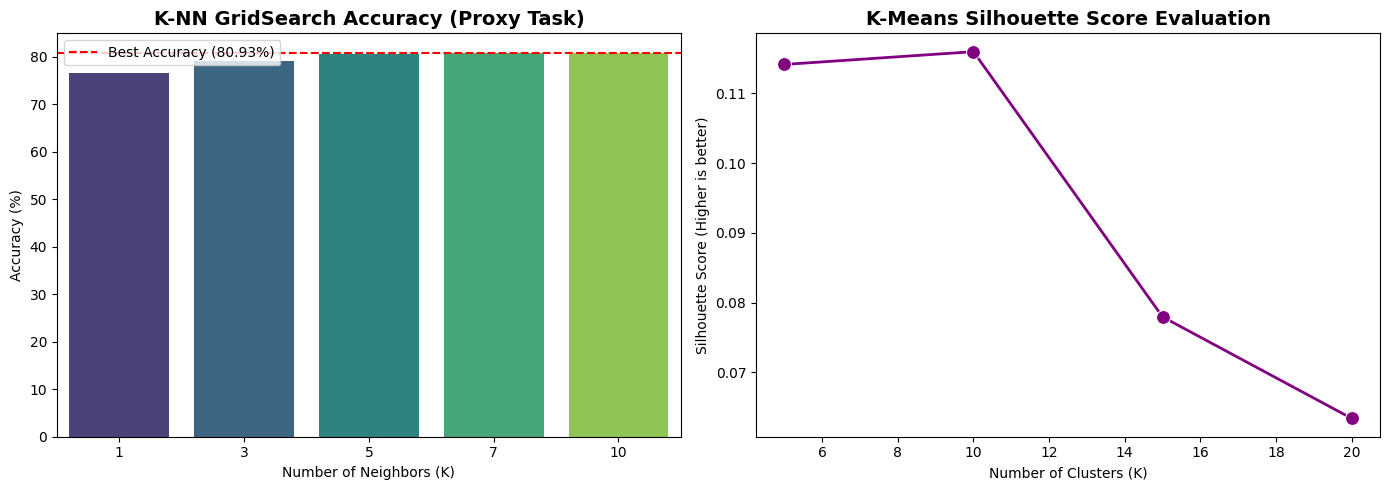

In [31]:

print("Initiating Hyperparameter Tuning (GridSearch & Silhouette Analysis)\n")

# Set Random Seed for Reproducibility (Scientific Rigor)
np.random.seed(42)

# --- 1. GridSearch: Proxy Task for K-NN (Fix: Data Leakage Prevention) ---
# Use Pipeline to combine the Scaler and K-NN so that the scale is recalculated each time the data is folded
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {'knn__n_neighbors': [1, 3, 5, 7, 10]}
grid_knn = GridSearchCV(pipeline, param_grid_knn, cv=3, scoring='accuracy', n_jobs=-1)

# Sample 3000 rows to speed up tuning
sample_size = min(3000, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)

# Replace X_scaled with X_raw to prevent data leakage.
grid_knn.fit(X_raw[sample_idx], df.iloc[sample_idx]['Gen_Pos'])

best_k_knn = grid_knn.best_params_['knn__n_neighbors']
best_knn_acc = grid_knn.best_score_ * 100

# --- 2. Custom GridSearch: Silhouette Score for K-Means ---
k_values = [5, 10, 15, 20]
silhouette_scores = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_temp = kmeans_temp.fit_predict(X_scaled[sample_idx])
    score = silhouette_score(X_scaled[sample_idx], labels_temp)
    silhouette_scores.append(score)

best_k_kmeans = k_values[np.argmax(silhouette_scores)]

print(f"K-NN Optimal Parameter   : K = {best_k_knn} (Proxy Task Accuracy: {best_knn_acc:.2f}%)")
print(f"K-Means Optimal Cluster  : K = {best_k_kmeans} (Highest Silhouette Score)\n")
print("Generating Visual Analytics for Model Evaluation")

# Visual Analytics #1: Evaluation Charts
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=[str(k) for k in param_grid_knn['knn__n_neighbors']], y=grid_knn.cv_results_['mean_test_score']*100, ax=ax[0], palette="viridis")
ax[0].set_title("K-NN GridSearch Accuracy (Proxy Task)", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Number of Neighbors (K)")
ax[0].set_ylabel("Accuracy (%)")
ax[0].axhline(best_knn_acc, color='red', linestyle='--', label=f'Best Accuracy ({best_knn_acc:.2f}%)')
ax[0].legend()

sns.lineplot(x=k_values, y=silhouette_scores, marker='o', color='purple', linewidth=2, markersize=10, ax=ax[1])
ax[1].set_title("K-Means Silhouette Score Evaluation", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score (Higher is better)")

plt.tight_layout()
plt.show()

## Step 6: Interactive Scouting Radar (Deployment Simulation)
**Objective:** Encapsulate the entire AI pipeline (Targeting, Dynamic Weighting, Multi-Model Execution, and Visual Analytics) into a single interactive Web Application interface.

This section simulates a **deployment** system for use by scouting teams without requiring any backend coding. When the target player's name is entered:
1. The system will extract the target's **playstyle DNA**.
2. Automatically adjust the weight of the scale (Contextual Feature Scaling).
3. Send the data to 5 AI models to calculate the distance.
4. Display the results as a real-time **dashboard**.

In [ ]:
def run_scouting_radar(search_name):
    target_matches = df[df['Name'].str.contains(search_name, case=False, na=False)]

    if len(target_matches) == 0:
        print(f"Target player '{search_name}' not found. Please try another name.")
        return 
        
    # --- Fix: Prevent duplicate names (Disambiguation Check) ---
    if len(target_matches) > 1:
        exact_match = target_matches[target_matches['Name'].str.lower() == search_name.lower()]
        if len(exact_match) == 1:
            target_idx = exact_match.index[0]
        else:
            print(f"Found {len(target_matches)} players matching '{search_name}'. Please be more specific (e.g., type full name):")
            for _, row in target_matches.head(5).iterrows():
                print(f"   - {row['Name']} ({row['Club']})")
            if len(target_matches) > 5: print("   ... and more.")
            return 
    else:
        target_idx = target_matches.index[0]
        
    target_player = df.iloc[target_idx]
    TARGET_NAME = target_player['Name']
    
    print(f"Target Identified: {target_player['Display_Name']} | Position: {target_player['Gen_Pos']} | Age: {target_player['Age']} | Market Value: £{target_player['Values']:,.0f}")
    
    candidates_idx = df.index != target_idx
    X_cands = X_scaled[candidates_idx]
    cand_df = df[candidates_idx].reset_index(drop=True)
    target_vec = X_scaled[target_idx].reshape(1, -1)
    
    # --- Dynamic Feature Weighting ---
    weights = np.ones(target_vec.shape[1])
    finance_cols = ['Values', 'Salary', 'Current reputation', 'Domestic reputation', 'World reputation']
    national_cols = ['Number of national team appearances', 'Goals scored for the national team']
    hidden_cols = ['Adaptation', 'Ambition', 'Argue', 'Loyal', 'Resistant to stress', 'Professional', 'Sportsmanship', 'Emotional control']
    gk_cols = ['Aerial Reach', 'Command Of Area', 'Communication', 'Eccentricity', 'Handling', 'Kicking', 'One On Ones', 'Reflexes', 'Rushing Out', 'Punching', 'Throwing']
    outfield_cols = ['Finishing', 'Dribbling', 'Crossing', 'Long Throws', 'Corners', 'Free Kick Taking', 'Penalty Taking', 'Heading', 'Long Shots']
    
    is_gk = target_player['Gen_Pos'] == 'GK'
    
    for i, col in enumerate(available_ml_features):
        if col in finance_cols: weights[i] = 0.20
        elif col in national_cols: weights[i] = 0.10
        elif col in hidden_cols: weights[i] = 0.50
            
        if is_gk:
            if col in outfield_cols: weights[i] = 0.01
            elif col in gk_cols: weights[i] = 2.00
        else:
            if col in gk_cols: weights[i] = 0.01
                
    base_weighted_target = target_vec[0] * weights
    top_5_idx = np.argsort(base_weighted_target)[-5:]
    weights[top_5_idx] *= 1.5
    
    target_weighted = target_vec * weights
    X_cands_weighted = X_cands * weights
    
    # --- Multi-Model Execution ---
    def dist_to_pct(dist, max_dist=15.0):
        return np.clip(100 - (dist / max_dist) * 100, 0, 100)
    
    top5_results = {}

    knn = NearestNeighbors(n_neighbors=5, metric='euclidean')
    knn.fit(X_cands_weighted)
    dists_knn, idx_knn = knn.kneighbors(target_weighted)
    top5_results['K-NN (The Clone)'] = [{'Name': cand_df.iloc[idx_knn[0][i]]['Name'], 'Score': dist_to_pct(dists_knn[0][i]), 'Age': cand_df.iloc[idx_knn[0][i]]['Age'], 'CA': cand_df.iloc[idx_knn[0][i]]['ca']} for i in range(5)]

    sim_matrix = cosine_similarity(target_weighted, X_cands_weighted)[0]
    cos_idx = np.argsort(sim_matrix)[::-1][:5]
    top5_results['Cosine (Style Match)'] = [{'Name': cand_df.iloc[i]['Name'], 'Score': np.clip(sim_matrix[i] * 100, 0, 100), 'Age': cand_df.iloc[i]['Age'], 'CA': cand_df.iloc[i]['ca']} for i in cos_idx]

    rnn = NearestNeighbors(radius=15.0, metric='euclidean')
    rnn.fit(X_cands_weighted)
    dists_rnn, idx_rnn = rnn.radius_neighbors(target_weighted, sort_results=True)
    top5_results['Radius NN (Strict Filter)'] = [{'Name': cand_df.iloc[idx_rnn[0][i]]['Name'], 'Score': dist_to_pct(dists_rnn[0][i]), 'Age': cand_df.iloc[idx_rnn[0][i]]['Age'], 'CA': cand_df.iloc[idx_rnn[0][i]]['ca']} for i in range(min(5, len(idx_rnn[0])))]

    kmeans = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
    km_labels = kmeans.fit_predict(np.vstack([target_weighted, X_cands_weighted]))
    same_cluster = np.where(km_labels[1:] == km_labels[0])[0]
    
    km_list = []
    if len(same_cluster) > 0:
        dists_km = np.linalg.norm(X_cands_weighted[same_cluster] - target_weighted, axis=1)
        sorted_sub_idx = np.argsort(dists_km)[:5]
        km_list = [{'Name': cand_df.iloc[same_cluster[i]]['Name'], 'Score': dist_to_pct(dists_km[i]), 'Age': cand_df.iloc[same_cluster[i]]['Age'], 'CA': cand_df.iloc[same_cluster[i]]['ca']} for i in sorted_sub_idx]
    top5_results['K-Means (Tactical Group)'] = km_list

    # --- Fix: DBSCAN Dynamic Epsilon ---
    dynamic_eps = np.mean(dists_knn[0]) * 1.2 # Calculate the radius based on K-NN.
    dbscan = DBSCAN(eps=dynamic_eps, min_samples=2)
    db_labels = dbscan.fit_predict(np.vstack([target_weighted, X_cands_weighted]))
    
    if db_labels[0] == -1:
        top5_results['DBSCAN (Outlier Detector)'] = [{'Name': f'🚨 OUTLIER (Eps: {dynamic_eps:.1f})', 'Score': 0, 'Age': 0, 'CA': 0}]
    else:
        same_db = np.where(db_labels[1:] == db_labels[0])[0]
        dists_db = np.linalg.norm(X_cands_weighted[same_db] - target_weighted, axis=1)
        sorted_sub_idx = np.argsort(dists_db)[:5]
        top5_results['DBSCAN (Outlier Detector)'] = [{'Name': cand_df.iloc[same_db[i]]['Name'], 'Score': dist_to_pct(dists_db[i]), 'Age': cand_df.iloc[same_db[i]]['Age'], 'CA': cand_df.iloc[same_db[i]]['ca']} for i in sorted_sub_idx]

    # --- Visual Analytics ---
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten() 
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#e74c3c']
    
    for idx, (model_name, top_players) in enumerate(top5_results.items()):
        ax = axes[idx]
        if len(top_players) == 0 or top_players[0]['Name'].startswith('🚨'):
            ax.text(0.5, 0.5, top_players[0]['Name'] if len(top_players)>0 else 'NO MATCH FOUND', horizontalalignment='center', verticalalignment='center', fontsize=14, color='red', transform=ax.transAxes)
            ax.set_title(model_name, fontsize=14, fontweight='bold')
            ax.axis('off')
            continue

        names = [f"{p['Name']} (CA:{int(p['CA'])})" for p in top_players][::-1]
        scores = [p['Score'] for p in top_players][::-1]
        
        bars = ax.barh(names, scores, color=colors[idx % 5], alpha=0.8, edgecolor='black')
        for bar in bars:
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', ha='left', fontsize=11, fontweight='bold')
            
        ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
        ax.set_xlim(0, 100) 
        ax.set_xlabel('Match / Similarity (%)', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    model_names_short = []
    max_scores = []
    min_scores = []
    
    for idx, (m_name, top_players) in enumerate(top5_results.items()):
        short_name = m_name.split(' (')[0]
        model_names_short.append(short_name)
        
        # Pull the score of the first person (Max) and the last person on the list (Min of Top 5)
        if len(top_players) > 0 and not top_players[0]['Name'].startswith('🚨'):
            max_scores.append(top_players[0]['Score'])
            min_scores.append(top_players[-1]['Score']) 
        else:
            max_scores.append(0.0)
            min_scores.append(0.0)

    # Flip the data so that it is arranged from top to bottom, like the other graphs
    model_names_short = model_names_short[::-1]
    max_scores = max_scores[::-1]
    min_scores = min_scores[::-1]

    # Set up the graph for channel 6
    ax6 = axes[5]
    ax6.axis('on') 
    
    # Calculate the position and size of the pair of bar graphs
    y = np.arange(len(model_names_short))
    bar_height = 0.35
    
    # Draw the Max (Green) and Min (Red) bars
    bars_max = ax6.barh(y + bar_height/2, max_scores, bar_height, color="#198754", alpha=0.9, edgecolor='black')
    bars_min = ax6.barh(y - bar_height/2, min_scores, bar_height, color="#dc3545", alpha=0.9, edgecolor='black',)
    
    # Center the Y-axis label between the two bars
    ax6.set_yticks(y)
    ax6.set_yticklabels(model_names_short, fontsize=10, fontweight='bold')
    
    # Add a number to the end of the Max bar
    for bar in bars_max:
        if bar.get_width() > 0:
            ax6.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                    f'{bar.get_width():.1f}%', 
                    va='center', ha='left', fontsize=10, fontweight='bold', color='#198754')
            
    # Place a number at the end of the Min bar
    for bar in bars_min:
        if bar.get_width() > 0:
            ax6.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                    f'{bar.get_width():.1f}%', 
                    va='center', ha='left', fontsize=10, fontweight='bold', color='#dc3545')
        
    ax6.set_title("Model Variance (Max vs Min in Top 5)", fontsize=14, fontweight='bold', color="#000000")
    ax6.set_xlim(0, 100) 
    ax6.set_xlabel('Match / Similarity (%)', fontsize=10)
    ax6.spines['top'].set_visible(False)
    ax6.spines['right'].set_visible(False)
    ax6.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Place the legend (color description) above the graph
    ax6.legend(loc='lower left', bbox_to_anchor=(0, 1.02), ncol=2, frameon=False, fontsize=10)
    
    # Summary of table header names
    plt.suptitle(f"Scouting Radar: Top 5 Replacement Analysis for '{TARGET_NAME}'", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()

# Create UI
style = {'description_width': 'initial'}
search_box = widgets.Text(
    value='',
    description='Target Player Name:',
    style=style,
    layout=widgets.Layout(width='400px')
)
search_button = widgets.Button(
    description='Search DNA',
    button_style='success',
    tooltip='Click to run the AI models',
    icon='search'
)
output_area = widgets.Output()

def on_button_clicked(b):
    with output_area:
        clear_output(wait=True) 
        print("AI is analyzing 98 dimensions across global database")
        run_scouting_radar(search_box.value)

search_button.on_click(on_button_clicked)

display(widgets.HBox([search_box, search_button]))
display(output_area)

Output()